In [36]:
from google.colab import drive
drive.mount('/content/drive')

!pip install rasterio geopandas numpy matplotlib pillow -q


PROJECT = '/content/drive/MyDrive/GeoVLM_Project'
DATA_RAW = f'{PROJECT}/data/raw'
DATA_PROCESSED = f'{PROJECT}/data/processed'

os.makedirs(DATA_PROCESSED, exist_ok=True)

print("Setup complete ✓")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete ✓


In [40]:
import json
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

from sklearn.model_selection import train_test_split


In [4]:
# Extract xBD training data into Colab temp storage
!tar -xf '/content/drive/MyDrive/GeoVLM_Project/data/raw/train_images_labels_targets.tar' -C '/content/'

print("Extraction complete ✓")

# Check what's inside
for folder in os.listdir('/content/'):
    print(folder)

Extraction complete ✓
.config
drive
train
sample_data


Verifying the data


In [10]:
train_path = '/content/train'
images = os.listdir(f'{train_path}/images')
labels = os.listdir(f'{train_path}/labels')
targets = os.listdir(f'{train_path}/targets')

print(f'Number of images: {len(images)}')
print(f'Number of labels: {len(labels)}')
print(f'Number of targets: {len(targets)}')

Number of images: 5598
Number of labels: 5598
Number of targets: 5598


In [5]:
# image_path = '/content/train/images/guatemala-volcano_00000000_post_disaster.png'
# img = Image.open(image_path)
# print(f"The dimension of the image is: {img.size}")

The dimension of the image is: (1024, 1024)


In [12]:
print(f"\nSample image: {images[:3]}")
# print(f"Sample label: {labels[:3]}")
# print(f"Sample target: {targets[0]}


Sample image: ['santa-rosa-wildfire_00000304_pre_disaster.png', 'hurricane-harvey_00000493_pre_disaster.png', 'socal-fire_00000115_post_disaster.png']
Sample label: ['hurricane-florence_00000319_pre_disaster.json', 'midwest-flooding_00000197_pre_disaster.json', 'midwest-flooding_00000290_post_disaster.json']


Visualization of the data samples

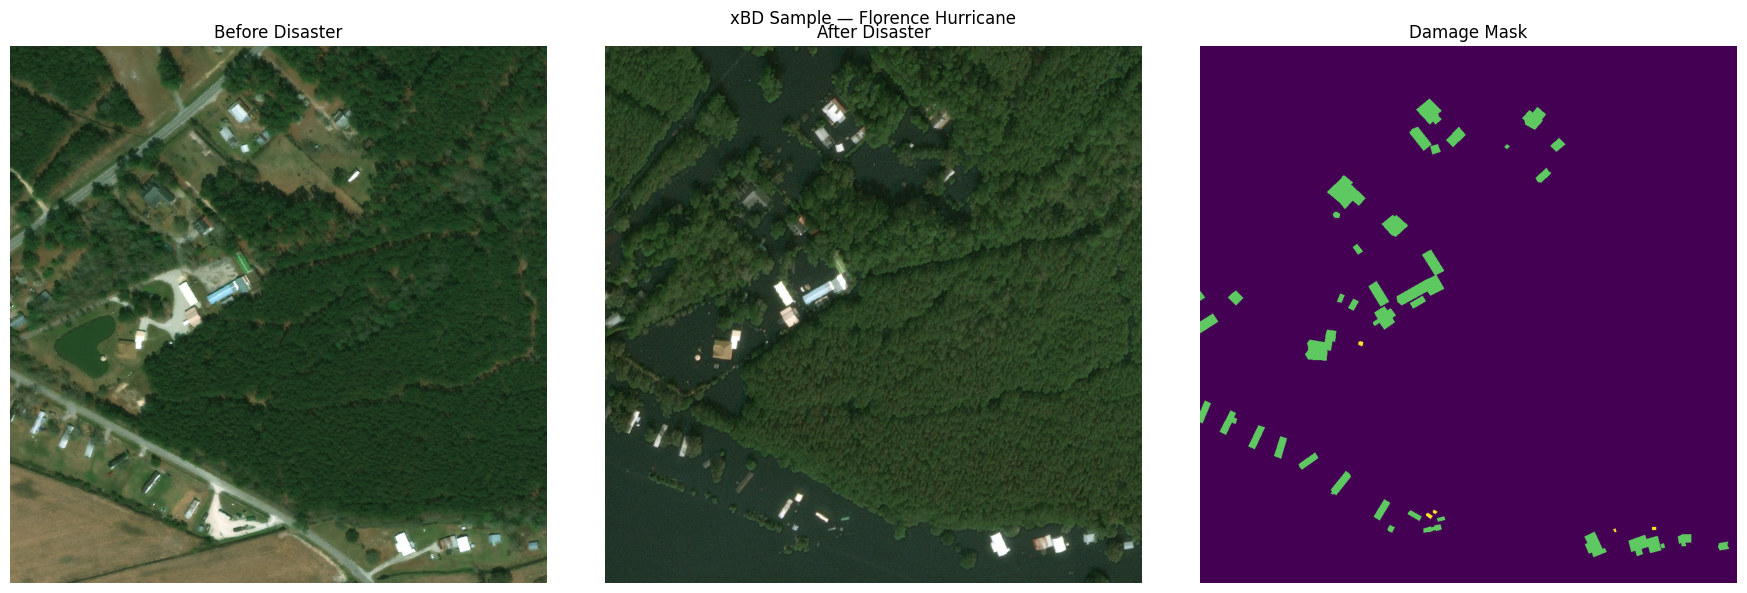

Image size: (1024, 1024)
Label keys: dict_keys(['features', 'metadata'])


In [19]:
# Redefine as proper paths
train_images = '/content/train/images'
train_labels = '/content/train/labels'
train_targets = '/content/train/targets'

# Pick one sample
sample = 'hurricane-florence_00000018_pre_disaster'

# Load images
pre_img = Image.open(f'{train_images}/{sample}.png')
post_img = Image.open(f'{train_images}/{sample.replace("pre_disaster", "post_disaster")}.png')
target = Image.open(f'{train_targets}/{sample.replace("pre_disaster", "post_disaster_target")}.png')

# Load label
with open(f'{train_labels}/{sample}.json') as f:
    label = json.load(f)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(pre_img)
axes[0].set_title('Before Disaster')
axes[0].axis('off')

axes[1].imshow(post_img)
axes[1].set_title('After Disaster')
axes[1].axis('off')

axes[2].imshow(target)
axes[2].set_title('Damage Mask')
axes[2].axis('off')

plt.suptitle('xBD Sample — Florence Hurricane')
plt.tight_layout()
plt.show()

print(f"Image size: {pre_img.size}")
print(f"Label keys: {label.keys()}")

Let's Check the Damage Labels

Damage distribution for this image:
-----------------------------------
  no-damage           : 10 buildings
  Total               : 10 buildings


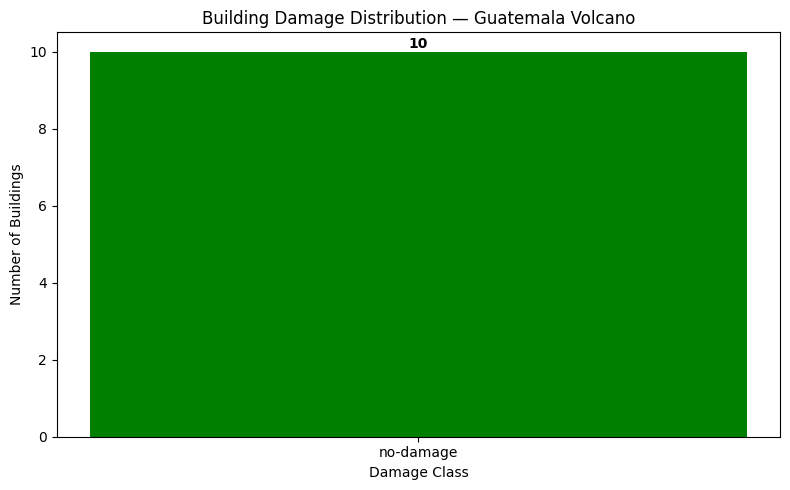

In [33]:

# post disaster label loaded
with open(f'{train_labels}/guatemala-volcano_00000000_post_disaster.json') as f:
    post_label = json.load(f)

#  damage classes counts
features = post_label['features']['xy']
damage_counts = {}

for feature in features:
    damage = feature['properties']['subtype']
    damage_counts[damage] = damage_counts.get(damage, 0) + 1

#  damage distribution
print("Damage distribution for this image:")
print("-" * 35)
for damage_type, count in damage_counts.items():
    print(f"  {damage_type:20s}: {count} buildings")
print(f"  {'Total':20s}: {sum(damage_counts.values())} buildings")

# Visualize as bar chart
plt.figure(figsize=(8, 5))
colors = {
    'no-damage': 'green',
    'minor-damage': 'yellow',
    'major-damage': 'orange',
    'destroyed': 'red',
    'un-classified': 'grey'
}

bars = plt.bar(
    damage_counts.keys(),
    damage_counts.values(),
    color=[colors.get(k, 'blue') for k in damage_counts.keys()]
)

# Adding count on top of each bar
for bar, count in zip(bars, damage_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             str(count),
             ha='center', fontweight='bold')

plt.title('Building Damage Distribution — Guatemala Volcano')
plt.xlabel('Damage Class')
plt.ylabel('Number of Buildings')
plt.tight_layout()
plt.show()

Damage distribution for this image:
-----------------------------------
  destroyed           : 511 buildings
  no-damage           : 79 buildings
  major-damage        : 24 buildings
  Total               : 614 buildings


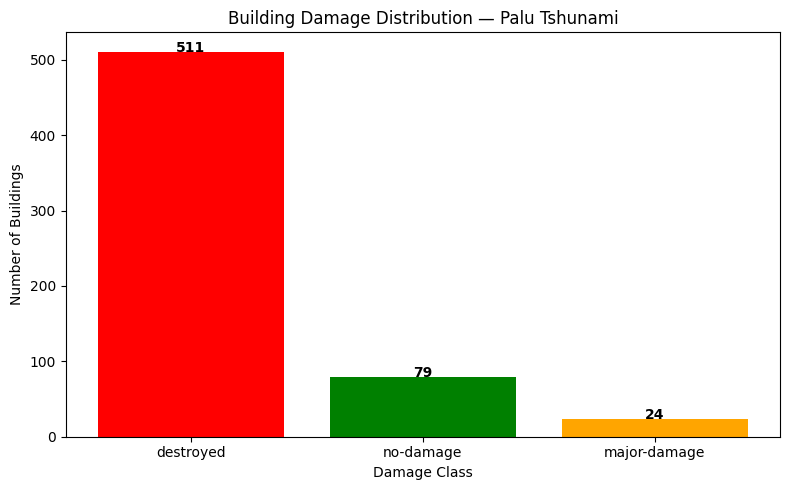

In [31]:

# post disaster label loaded
with open(f'{train_labels}/palu-tsunami_00000182_post_disaster.json') as f:
    post_label = json.load(f)

#  damage classes counts
features = post_label['features']['xy']
damage_counts = {}

for feature in features:
    damage = feature['properties']['subtype']
    damage_counts[damage] = damage_counts.get(damage, 0) + 1

#  damage distribution
print("Damage distribution for this image:")
print("-" * 35)
for damage_type, count in damage_counts.items():
    print(f"  {damage_type:20s}: {count} buildings")
print(f"  {'Total':20s}: {sum(damage_counts.values())} buildings")

# Visualize as bar chart
plt.figure(figsize=(8, 5))
colors = {
    'no-damage': 'green',
    'minor-damage': 'yellow',
    'major-damage': 'orange',
    'destroyed': 'red',
    'un-classified': 'grey'
}

bars = plt.bar(
    damage_counts.keys(),
    damage_counts.values(),
    color=[colors.get(k, 'blue') for k in damage_counts.keys()]
)

# Adding count on top of each bar
for bar, count in zip(bars, damage_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.1,
             str(count),
             ha='center', fontweight='bold')

plt.title('Building Damage Distribution — Palu Tshunami')
plt.xlabel('Damage Class')
plt.ylabel('Number of Buildings')
plt.tight_layout()
plt.show()

In [32]:

damage_summary = []

for label_file in os.listdir(train_labels):
    # only look at post disaster labels
    if 'post_disaster' not in label_file:
        continue

    with open(f'{train_labels}/{label_file}') as f:
        label = json.load(f)

    features = label['features']['xy']
    counts = {'destroyed': 0, 'major-damage': 0,
              'minor-damage': 0, 'no-damage': 0}

    for feature in features:
        damage = feature['properties']['subtype']
        if damage in counts:
            counts[damage] += 1

    if counts['destroyed'] > 0:
        damage_summary.append({
            'file': label_file,
            'destroyed': counts['destroyed'],
            'major': counts['major-damage'],
            'minor': counts['minor-damage'],
            'no_damage': counts['no-damage']
        })

# Sort by most destroyed
damage_summary.sort(key=lambda x: x['destroyed'], reverse=True)

print("Top 10 images with most destroyed buildings:")
print("-" * 60)
for item in damage_summary[:10]:
    print(f"{item['file']}")
    print(f"  destroyed: {item['destroyed']} | major: {item['major']} | minor: {item['minor']}")
    print()

Top 10 images with most destroyed buildings:
------------------------------------------------------------
palu-tsunami_00000118_post_disaster.json
  destroyed: 1540 | major: 9 | minor: 0

palu-tsunami_00000182_post_disaster.json
  destroyed: 511 | major: 24 | minor: 0

palu-tsunami_00000178_post_disaster.json
  destroyed: 223 | major: 3 | minor: 0

santa-rosa-wildfire_00000084_post_disaster.json
  destroyed: 207 | major: 0 | minor: 0

santa-rosa-wildfire_00000063_post_disaster.json
  destroyed: 206 | major: 1 | minor: 0

santa-rosa-wildfire_00000155_post_disaster.json
  destroyed: 203 | major: 0 | minor: 1

palu-tsunami_00000069_post_disaster.json
  destroyed: 197 | major: 18 | minor: 0

palu-tsunami_00000125_post_disaster.json
  destroyed: 197 | major: 53 | minor: 0

palu-tsunami_00000168_post_disaster.json
  destroyed: 175 | major: 0 | minor: 0

santa-rosa-wildfire_00000161_post_disaster.json
  destroyed: 168 | major: 1 | minor: 1



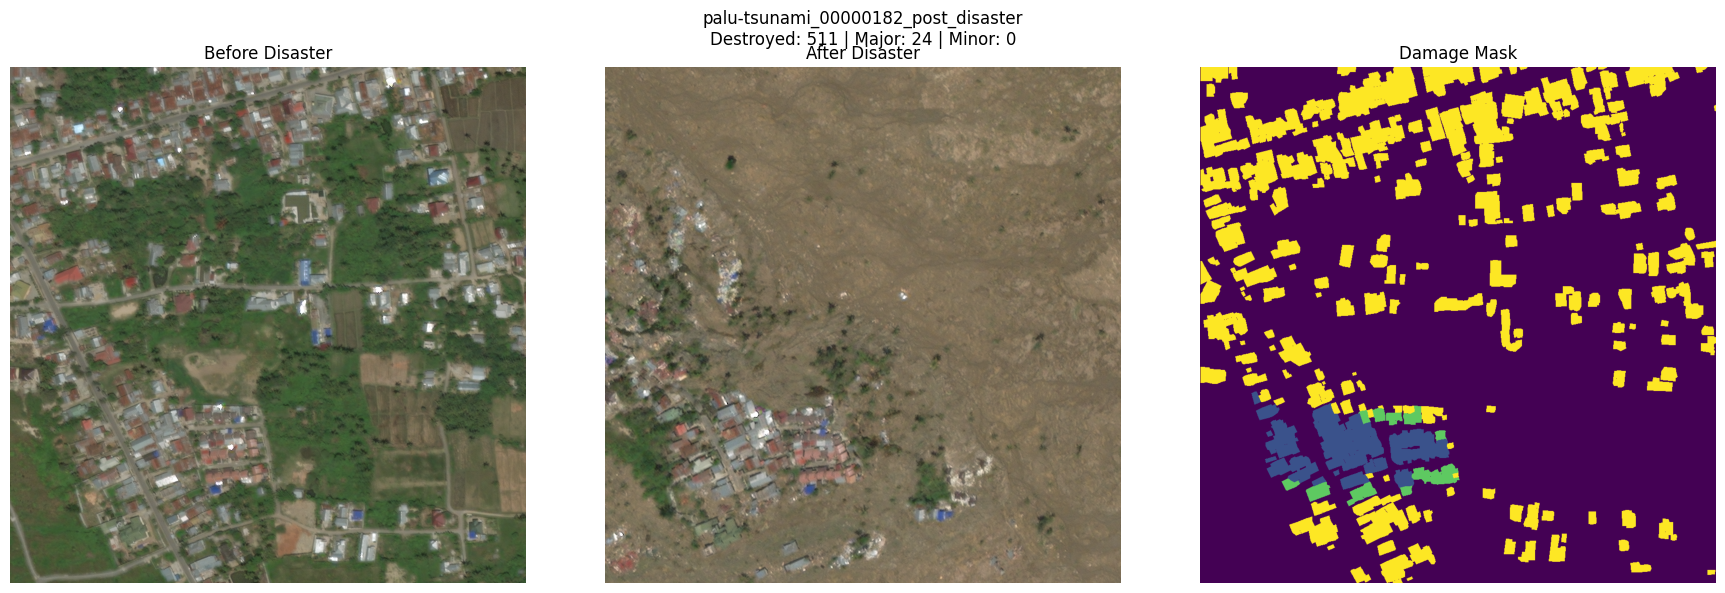

In [30]:

sample_post = 'palu-tsunami_00000182_post_disaster'
sample_pre = sample_post.replace('post_disaster', 'pre_disaster')

#  images
pre_img = Image.open(f'{train_images}/{sample_pre}.png')
post_img = Image.open(f'{train_images}/{sample_post}.png')
target = Image.open(f'{train_targets}/{sample_post}_target.png')

#  label
with open(f'{train_labels}/{sample_post}.json') as f:
    label = json.load(f)

# Count damage
features = label['features']['xy']
damage_counts = {}
for feature in features:
    damage = feature['properties']['subtype']
    damage_counts[damage] = damage_counts.get(damage, 0) + 1

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(pre_img)
axes[0].set_title('Before Disaster')
axes[0].axis('off')

axes[1].imshow(post_img)
axes[1].set_title('After Disaster')
axes[1].axis('off')

axes[2].imshow(target)
axes[2].set_title('Damage Mask')
axes[2].axis('off')

plt.suptitle(f'{sample_post}\nDestroyed: {damage_counts.get("destroyed", 0)} | Major: {damage_counts.get("major-damage", 0)} | Minor: {damage_counts.get("minor-damage", 0)}')
plt.tight_layout()
plt.show()

Step-6 Create damage masks from JSON labels

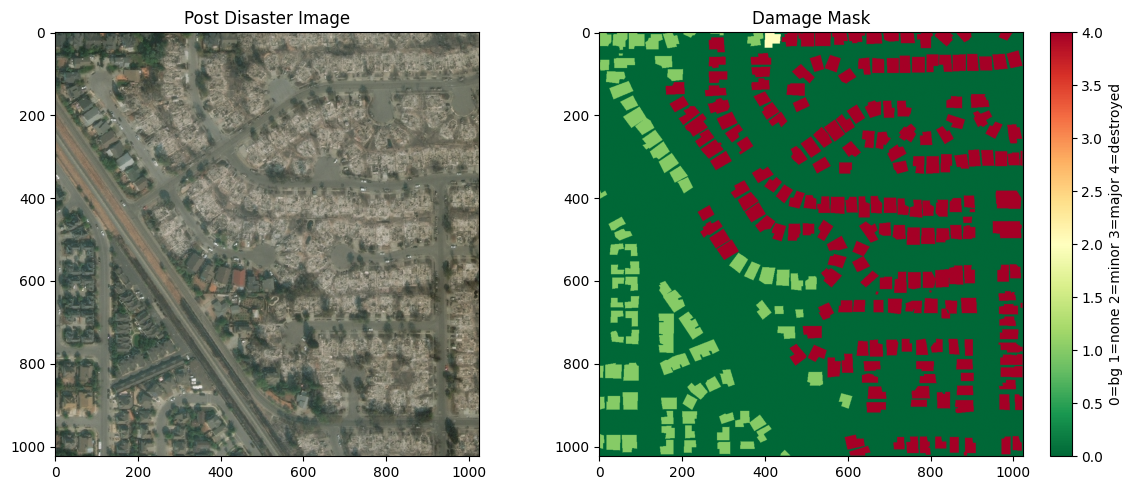

Mask shape: (1024, 1024)
Unique values: [0 1 2 4]


In [38]:
def create_damage_mask(label_path, image_size=(1024, 1024)):
    """
    Converts xBD JSON labels into a pixel mask
    0 = background
    1 = no damage
    2 = minor damage
    3 = major damage
    4 = destroyed
    """
    with open(label_path) as f:
        label = json.load(f)

    mask = Image.new('L', image_size, 0)
    draw = ImageDraw.Draw(mask)

    damage_map = {
        'no-damage':     1,
        'minor-damage':  2,
        'major-damage':  3,
        'destroyed':     4,
        'un-classified': 0
    }

    features = label['features']['xy']
    for feature in features:
        damage = feature['properties']['subtype']
        coords = feature['wkt']

        # Parse polygon coordinates
        try:
            from shapely import wkt
            polygon = wkt.loads(coords)
            xy = list(polygon.exterior.coords)
            xy = [(int(x), int(y)) for x, y in xy]
            draw.polygon(xy, fill=damage_map.get(damage, 0))
        except:
            continue

    return np.array(mask)

# Test on one sample
sample = 'santa-rosa-wildfire_00000155_post_disaster'
mask = create_damage_mask(f'{train_labels}/{sample}.json')

# Visualize
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(Image.open(f'{train_images}/{sample}.png'))
plt.title('Post Disaster Image')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='RdYlGn_r', vmin=0, vmax=4)
plt.colorbar(label='0=bg 1=none 2=minor 3=major 4=destroyed')
plt.title('Damage Mask')
plt.tight_layout()
plt.show()

print("Mask shape:", mask.shape)
print("Unique values:", np.unique(mask))

 Chip images into patches which Cuts large 1024x1024 images into smaller 256x256 patches
stride=128 means 50% overlap between patches

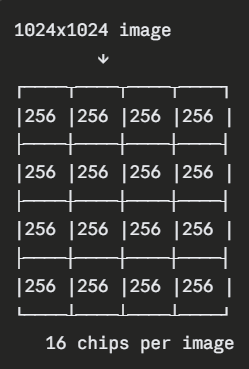


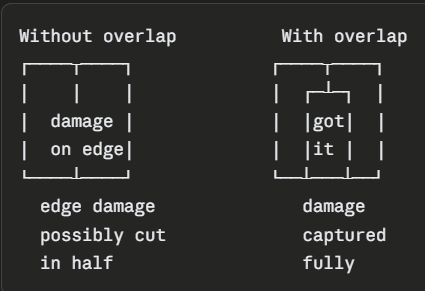

Total chips created: 49
Chip image shape: (256, 256, 6)
Chip mask shape: (256, 256)


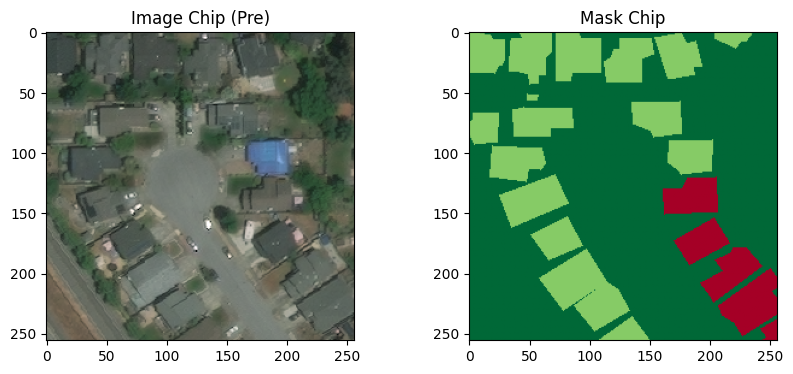

In [42]:
def chip_image(image_array, mask_array, chip_size=256, stride=128):
    """
    Cuts large 1024x1024 images into smaller 256x256 patches
    stride=128 means 50% overlap between patches
    """
    chips_img = []
    chips_mask = []

    h, w = image_array.shape[:2]

    for y in range(0, h - chip_size + 1, stride):
        for x in range(0, w - chip_size + 1, stride):
            img_chip = image_array[y:y+chip_size, x:x+chip_size]
            mask_chip = mask_array[y:y+chip_size, x:x+chip_size]

            # Only keep chips that have some buildings
            if mask_chip.max() > 0:
                chips_img.append(img_chip)
                chips_mask.append(mask_chip)

    return chips_img, chips_mask

# Test chipping on one sample
sample_post = 'santa-rosa-wildfire_00000155_post_disaster'
sample_pre  = 'santa-rosa-wildfire_00000155_pre_disaster'

post_img = np.array(Image.open(f'{train_images}/{sample_post}.png'))
pre_img  = np.array(Image.open(f'{train_images}/{sample_pre}.png'))
mask     = create_damage_mask(f'{train_labels}/{sample_post}.json')

# Stack pre and post as 6-channel input (3 bands each)
stacked = np.concatenate([pre_img[:,:,:3], post_img[:,:,:3]], axis=2)

chips_img, chips_mask = chip_image(stacked, mask)

print(f"Total chips created: {len(chips_img)}")
print(f"Chip image shape: {chips_img[0].shape}")
print(f"Chip mask shape: {chips_mask[0].shape}")

# Visualize one chip
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(chips_img[0][:,:,:3])
plt.title('Image Chip (Pre)')
plt.subplot(1, 2, 2)
plt.imshow(chips_mask[0], cmap='RdYlGn_r')
plt.title('Mask Chip')
plt.show()

Step 8 — Process all disasters and split train/val

In [41]:
all_chips_img = []
all_chips_mask = []

# Get all post disaster images
post_images = [f for f in os.listdir(train_images) if 'post' in f]
print(f"Total post disaster images: {len(post_images)}")

# Process each image
for i, post_file in enumerate(post_images[:100]):  # start with 100 for speed
    try:
        pre_file = post_file.replace('post', 'pre')
        label_file = post_file.replace('.png', '.json')

        post_img  = np.array(Image.open(f'{train_images}/{post_file}'))
        pre_img   = np.array(Image.open(f'{train_images}/{pre_file}'))
        mask      = create_damage_mask(f'{train_labels}/{label_file}')

        # Stack pre+post
        stacked = np.concatenate([
            pre_img[:,:,:3],
            post_img[:,:,:3]
        ], axis=2)

        chips_img, chips_mask = chip_image(stacked, mask)
        all_chips_img.extend(chips_img)
        all_chips_mask.extend(chips_mask)

        if i % 10 == 0:
            print(f"Processed {i+1}/100 images — {len(all_chips_img)} chips so far")
    except:
        continue

print(f"\nTotal chips: {len(all_chips_img)}")

# Convert to numpy arrays
X = np.array(all_chips_img, dtype=np.float32) / 255.0
y = np.array(all_chips_mask, dtype=np.int64)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {X_train.shape} | Val: {X_val.shape}")

Total post disaster images: 2799
Processed 1/100 images — 26 chips so far
Processed 11/100 images — 214 chips so far
Processed 21/100 images — 433 chips so far
Processed 31/100 images — 728 chips so far
Processed 41/100 images — 926 chips so far
Processed 51/100 images — 1272 chips so far
Processed 61/100 images — 1511 chips so far
Processed 71/100 images — 1705 chips so far
Processed 81/100 images — 1916 chips so far
Processed 91/100 images — 2191 chips so far

Total chips: 2411
X shape: (2411, 256, 256, 6)
y shape: (2411, 256, 256)
Train: (1928, 256, 256, 6) | Val: (483, 256, 256, 6)


In [44]:

# Inside existing GeoVLM_Project folder
DATA_PROCESSED = '/content/drive/MyDrive/GeoVLM_Project/data/processed'

# Create folder
os.makedirs(DATA_PROCESSED, exist_ok=True)

# Save processed arrays to Drive
np.save(f'{DATA_PROCESSED}/X_train.npy', X_train)
np.save(f'{DATA_PROCESSED}/X_val.npy',   X_val)
np.save(f'{DATA_PROCESSED}/y_train.npy', y_train)
np.save(f'{DATA_PROCESSED}/y_val.npy',   y_val)

print("Saved to Drive ✓")
print(f"X_train: {X_train.shape} — {X_train.nbytes / 1e6:.1f} MB")
print(f"X_val:   {X_val.shape}   — {X_val.nbytes / 1e6:.1f} MB")


Saved to Drive ✓
X_train: (1928, 256, 256, 6) — 3032.5 MB
X_val:   (483, 256, 256, 6)   — 759.7 MB
